# GloVe Word Embeddings

Goal:

Replace sparse TF-IDF features with dense semantic word embeddings.

Pipeline:

Review
→ Tokens
→ GloVe vectors
→ Sentence embeddings
→ Logistic Regression
→ Evaluation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/imdb"
))

['imdb.csv', 'imdb_processed.csv']


In [3]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

os.makedirs(
    f"{PROJECT_ROOT}/data/glove",
    exist_ok=True
)

print("Ready")

Ready


In [4]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.8 MB/s eta 0:00:00


In [5]:
import gensim.downloader as api

glove = api.load(
    "glove-wiki-gigaword-100"
)

[==================================================] 100.0% 128.1/128.1MB downloaded


In [6]:
print(glove.vector_size)

print(
    glove["good"][:10]
)

100
[-0.030769  0.11993   0.53909  -0.43696  -0.73937  -0.15345   0.081126
 -0.38559  -0.68797  -0.41632 ]


In [7]:
print(
    glove.most_similar("good")
)

[('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126), ('kind', 0.8288268446922302), ('very', 0.8260800242424011), ('we', 0.8234355449676514), ('way', 0.8215398192405701), ('think', 0.8205099105834961), ('thing', 0.8171301484107971), ("'re", 0.8141680955886841)]


# Sentence Embeddings

Goal:

Convert an entire review into a single dense vector.

Method:

1. Look up GloVe vector for each word.
2. Average all vectors.
3. Result = review embedding.

In [8]:
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

df = pd.read_csv(
    f"{PROJECT_ROOT}/data/imdb/imdb_processed.csv"
)

df = df.head(5000).copy()

print(df.shape)

(5000, 3)


In [9]:
df.columns

Index(['review', 'sentiment', 'label'], dtype='object')

In [10]:
import numpy as np

def sentence_embedding(text):

    vectors = []

    for word in text.split():

        if word in glove:
            vectors.append(glove[word])

    if len(vectors) == 0:
        return np.zeros(glove.vector_size)

    return np.mean(vectors, axis=0)

In [12]:
X_glove = np.array([
    sentence_embedding(text)
    for text in df["review"]
])

print(X_glove.shape)

(5000, 100)


In [13]:
y_glove = (
    df["sentiment"]
    .map({
        "negative":0,
        "positive":1
    })
    .values
)

print(y_glove.shape)

(5000,)


In [14]:
import os

os.makedirs(
    f"{PROJECT_ROOT}/data/glove",
    exist_ok=True
)

np.save(
    f"{PROJECT_ROOT}/data/glove/X_glove.npy",
    X_glove
)

np.save(
    f"{PROJECT_ROOT}/data/glove/y_glove.npy",
    y_glove
)

print("Saved")

Saved


In [15]:
print(X_glove.shape)
print(y_glove.shape)

(5000, 100)
(5000,)


# Logistic Regression on GloVe Embeddings

Goal:

Train the same classifier used for TF-IDF, but using GloVe sentence embeddings instead.

This allows a fair comparison between:

- TF-IDF + Logistic Regression
- GloVe + Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split

X_train_glove, X_test_glove, y_train_glove, y_test_glove = train_test_split(
    X_glove,
    y_glove,
    test_size=0.2,
    random_state=42,
    stratify=y_glove
)

print(X_train_glove.shape)
print(X_test_glove.shape)

(4000, 100)
(1000, 100)


In [17]:
from sklearn.linear_model import LogisticRegression

glove_model = LogisticRegression(
    max_iter=1000
)

glove_model.fit(
    X_train_glove,
    y_train_glove
)

LogisticRegression(max_iter=1000)

In [18]:
y_pred_glove = glove_model.predict(
    X_test_glove
)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

glove_accuracy = accuracy_score(
    y_test_glove,
    y_pred_glove
)

glove_precision = precision_score(
    y_test_glove,
    y_pred_glove
)

glove_recall = recall_score(
    y_test_glove,
    y_pred_glove
)

glove_f1 = f1_score(
    y_test_glove,
    y_pred_glove
)

print("Accuracy :", glove_accuracy)
print("Precision:", glove_precision)
print("Recall   :", glove_recall)
print("F1       :", glove_f1)

Accuracy : 0.8
Precision: 0.8252212389380531
Recall   : 0.7550607287449392
F1       : 0.7885835095137421


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_glove,
        y_pred_glove
    )
)

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       506
           1       0.83      0.76      0.79       494

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



In [21]:
from sklearn.metrics import confusion_matrix

cm_glove = confusion_matrix(
    y_test_glove,
    y_pred_glove
)

cm_glove

array([[427,  79],
       [121, 373]])

# TF-IDF vs GloVe Comparison

In [22]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "TF-IDF + Logistic Regression",
        "GloVe + Logistic Regression"
    ],

    "Precision":[
        0.887,
        glove_precision
    ],

    "Recall":[
        0.812,
        glove_recall
    ],

    "F1":[
        0.848,
        glove_f1
    ]
})

comparison

,Model,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.887000,0.812000,0.848000
1,GloVe + Logistic Regression,0.825221,0.755061,0.788584


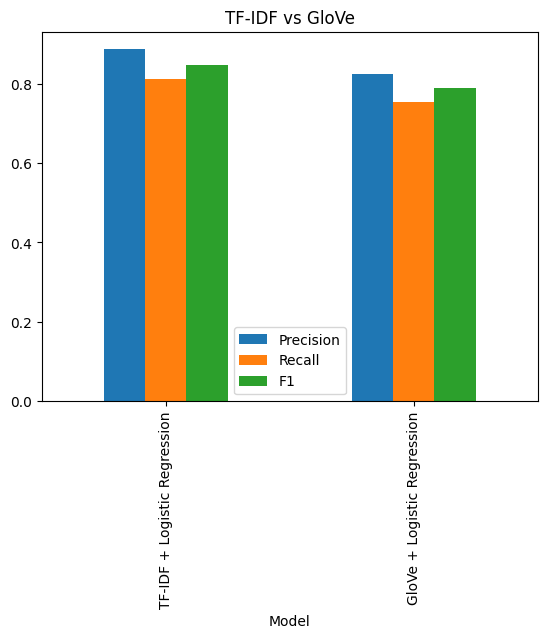

In [23]:
import matplotlib.pyplot as plt

comparison.set_index(
    "Model"
).plot(
    kind="bar"
)

plt.title(
    "TF-IDF vs GloVe"
)

plt.show()

In [24]:
import joblib

joblib.dump(
    glove_model,
    f"{PROJECT_ROOT}/models/nlp/glove_logistic_regression.pkl"
)


['/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/nlp/glove_logistic_regression.pkl']

# **Final NLP Model Selection**

Compared sparse TF-IDF features against dense GloVe embeddings. Despite GloVe's semantic representations, TF-IDF achieved higher performance (F1 = 0.848 vs 0.789), likely due to the keyword-heavy nature of IMDb sentiment classification and information loss introduced by mean-pooled embeddings.

**Models Evaluated:**

1. TF-IDF + Logistic Regression
2. TF-IDF + Naive Bayes
3. GloVe + Logistic Regression

**Results:**

| Model | F1 |
|---------|---------|
| TF-IDF + Logistic Regression | 0.848 |
| TF-IDF + Naive Bayes | 0.826 |
| GloVe + Logistic Regression | 0.789 |

**Selected Model:**

TF-IDF + Logistic Regression

**Reason:**

Highest F1 score and strongest overall balance between precision and recall.